In [2]:
%matplotlib widget

import matplotlib as mpl
import matplotlib
#matplotlib.use('TkAgg')
import matplotlib.pyplot as plt
import numpy as np
import math
from math import e, sqrt, pow, pi
import scipy
from IPython.display import display, Markdown, Latex
from scipy import stats
from matplotlib.patches import Circle, Ellipse, Polygon, Arrow

plt.style.use('default')
plt.interactive(True)

def GenSequenceUniform(n:int, mean:float, variance:float):
    b = mean + math.sqrt(3)*math.sqrt(variance)
    a = mean - math.sqrt(3)*math.sqrt(variance)
    seq = np.random.uniform(a, b, n)
    return seq
def GenSequenceGauss(n, mean, variance):
    return np.random.normal(mean, math.sqrt(variance), n)
def GenSequenceLaplace(n, mean, variance):
    return np.random.laplace(mean, math.sqrt(0.5*variance), n)
def GenSequenceCauchy(n, a, b):
    return stats.cauchy.rvs(a, b, n)

def DrawSequenceMeanVariance(seq, name, color, ymn:float|None=-3.0, ymx:float|None=7.0, mark = "."):
    fig = plt.figure()
    plt.interactive(True)
    plt.axis((0, len(seq), ymn, ymx))
    plt.xlabel("x")
    plt.ylabel("y")
    mean = np.mean(seq)
    var = np.var(seq)
    devh = mean + math.sqrt(var)
    devl = mean - math.sqrt(var)
    plt.plot(seq, color + mark, label="values");
    plt.axhline(mean, color = color, linestyle = "-",
                label="mean=" + str(round(mean, 3)))
    plt.axhline(np.var(seq), color = color, linestyle = "--",
                label="variance=" + str(round(var, 3)))
    plt.axhline(devh, color = color, linestyle = ":", label="standard deviation=" + str(round(math.sqrt(var), 3)))
    plt.axhline(devl, color = color, linestyle = ":")
    plt.title(name)
    plt.legend(title=name)
    plt.show(block=True)
    from matplotlib.patches import Circle, Ellipse, Polygon, Arrow

def GenSamplesF(n, f, mn, mx):
    samples = []
    while len(samples) < n:
        #p = ((i/n) * (mx-mn))+mn
        p = np.random.rand() * (mx-mn) + mn
        r = np.random.rand()
        #rand_points.append(r)
        if r <= f(p):
            samples.append(p)
    return samples

def ComputeDistribution(npoints, mn, mx, f, a, b):
    ret = []
    points = []
    for i in range(0, npoints):
        p = ((i/npoints) * (mx-mn))+mn
        points.append(p)
        ret.append(f(p, a, b))
    return ret, points
def HistogramCompare(seq, binwidth, points, dist, histlabel, plotlabel, title, axis = (None, None, None, None), color='g', alpha=0.75, show=True):
    fig = plt.figure()
    plt.title(title)
    plt.axis((min(seq) if axis[0] is None else axis[0], max(seq) if axis[1] is None else axis[1], axis[2], axis[3]))
    plt.hist(seq, bins=np.arange(min(seq), max(seq) + binwidth, binwidth), density=True, facecolor=color, alpha=alpha, label=histlabel)
    if points is not None:
        plt.plot(points, dist, label=plotlabel)
    plt.legend()
    if show:
        plt.show()
def Histogram(seq, binwidth, title, axis = (None, None, None, None), color='g', alpha=0.75, show=True):
    fig = plt.figure()
    plt.title(title)
    plt.axis((min(seq) if axis[0] is None else axis[0], max(seq) if axis[1] is None else axis[1], axis[2], axis[3]))
    plt.hist(seq, bins=np.arange(min(seq), max(seq) + binwidth, binwidth), density=True, facecolor=color, alpha=alpha)
    if show:
        plt.show()
gauss = lambda x, a, b: (1/math.sqrt(2*math.pi*b)) * math.exp(-(x - a)**2 / 2*b)
laplace = lambda x, a, b: (1/(2*b))*(math.e**-(abs(x-a)/b))
cauchy = lambda x, a, b:  (b/math.pi)/(b**2 + (x-a)**2)

# Exercise 15:

## Part 1:

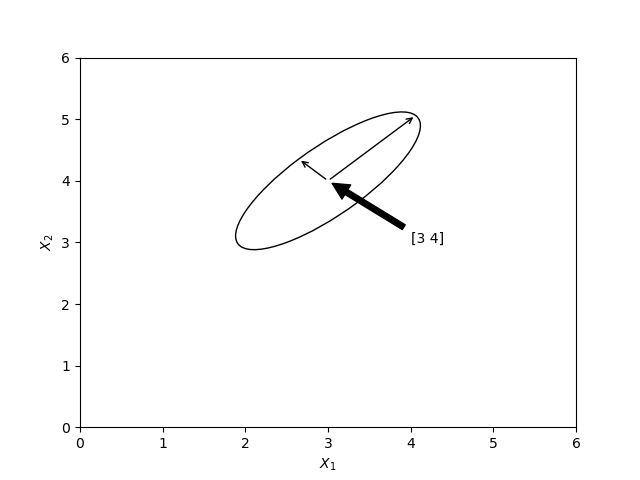

$P_{x_1x_2} = \frac{cov(x_1, x_2)}{σ_1σ_2} = 0.16 $

In [3]:
from matplotlib.patches import Circle, Ellipse, Polygon, Arrow
from numpy.linalg import norm

mx = np.array([[3], [4]])
Ex = np.array([[5, 4], [4, 5]])
W, Ev, Wt = np.linalg.svd(Ex)

Evals, Evecs = np.linalg.eig(Ex)

#ev0 = Evecs[0, :]
#ev1 = Evecs[1, :]
ev0 = np.array([Evecs[0, 0], Evecs[1, 0]])
ev1 = np.array([Evecs[0, 1], Evecs[1, 1]])

fig, ax = plt.subplots()

plt.style.use('default')
rot = np.arccos(np.dot(ev0, [0, 1]))
ax.add_patch(Ellipse((mx[0, 0], mx[1, 0]), sqrt(Ev[0]), sqrt(Ev[1]), angle=np.rad2deg(rot), fill=False))

meanp = np.array([mx[0, 0], mx[1, 0]])
plt.annotate(f"{meanp}", xy=meanp, xytext=meanp + np.array([1, -1]), arrowprops=dict(facecolor='black', shrink=0.05))

e0 = ev0 * np.sqrt(Ev[0])/2
e1 = ev1 * np.sqrt(Ev[1])/2
plt.annotate(f"", xy=e0+meanp, xytext=meanp, arrowprops=dict(arrowstyle = "->"))
plt.annotate(f"", xy=e1+meanp, xytext=meanp, arrowprops=dict(arrowstyle = "->"))
#ax.add_patch(Arrow(meanp[0], meanp[1], ev0[0], ev0[1]))
#ax.add_patch(Arrow(meanp[0], meanp[1], ev1[0], ev1[1]))

ax.set_xlabel("$X_1$")
ax.set_xlim(0, 6)
ax.set_ylabel("$X_2$")
ax.set_ylim(0, 6)

plt.show()

Px1x2 = Ex[0, 1]/(Ex[0, 0]*Ex[1,1])

display(Markdown("$P_{x_1x_2} = \\frac{cov(x_1, x_2)}{σ_1σ_2} = " + f"{Px1x2} $"))

#np.dot(W[0,:], W[:,0])[0, 0]




## Part 2: